# Firing rates (KS4)

author: laquitainesteeve@gmail.com

purpose: Validate firing rates from ks4

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

Required resources:

- RAM: 184 GB

## Setup

Prerequisites:

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download with notebooks/0_download_sortings.ipynb
4. Or Spike sort with: 
    - "_src/pipes/sorting/npx_vivo/10m/ks4.py_" 
    - "_src/pipes/sorting/npx_spont/10m/ks4.py_"
    - "_src/pipes/sorting/npx_evoked/10m/ks4.py_"
    - "_src/pipes/sorting/npx_synth/10m/ks4.py_"

In [12]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import numpy as np
import os
import warnings
import pandas as pd
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

# SET PROJECT PATH

PROJ_PATH = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(PROJ_PATH)
from src.nodes.utils import get_config, savefig
from src.nodes.validation import firing_rate as fr
from src.nodes.validation.npx_probe import firing_rate as fr_npx

# SETUP EXPERIMENTS

# setup kilosort4 sorting paths
SORTED_PATH_nv = "dataset/01_intermediate/sorting/marques/SortingKS4_10m"
SORTED_PATH_ns = "dataset/01_intermediate/sorting/npx_spont/SortingKS4_10m"
SORTED_PATH_ne = "dataset/01_intermediate/sorting/npx_evoked/SortingKS4_10m"
SORTED_PATH_nb = "dataset/01_intermediate/sorting/buccino/SortingKS4_10m"

# PARAMETERS
SINGLE_UNIT = True
layers = ["L1", "L2/3", "L4", "L5", "L6"]

# SETUP PLOT 

# set lognormal plot parameters
log_x_min = -3.0
log_x_max = 3.0
nbins = 30

# IF you don't want to use the feature, set the value to 1E100
# t_dec = 3600 # seconds until experimenter decides a cell is silent
t_dec = 1^100 # seconds until experimenter decides a cell is silent

cl = dict()
cl["COLOR_NV"] = [0.6, 0.6, 0.6]
cl["COLOR_NS"] = [0.9, 0.14, 0.15]
cl["COLOR_NB"] = [0.22, 0.5, 0.72] # blue
cl["COLOR_NE"] = [1, 0.49, 0] # orange
cl["COLOR_HV"] = "k" # black
cl["COLOR_HS"] = np.array([26, 152, 80]) / 255 # green

# axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically between 0.5 and 1
plt.rcParams["axes.linewidth"] = 0.5 #1
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# legend
legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.001}
LG_FRAMEON = False              # no legend frame

savefig_cfg = {"transparent":True, "dpi": 400}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get metadata

In [3]:
# get unit metadata
df_nv = fr.get_sorted_unit_meta(SORTED_PATH_nv)
df_ns = fr.get_sorted_unit_meta(SORTED_PATH_ns)
df_ne = fr.get_sorted_unit_meta(SORTED_PATH_ne)
df_nb = fr.get_synth_unit_meta(SORTED_PATH_nb)

# keep units in cortex
df_nv = df_nv[np.isin(df_nv["layer"], ["L1", "L2/3", "L4", "L5", "L6"])]
df_ns = df_ns[np.isin(df_ns["layer"], ["L1", "L2/3", "L4", "L5", "L6"])]
df_ne = df_ne[np.isin(df_ne["layer"], ["L1", "L2/3", "L4", "L5", "L6"])]

# unit-test: check all in cortex
assert all(
    np.isin(np.sort(df_nv["layer"].unique()), ["L1", "L2/3", "L4", "L5", "L6"])
), "nor all in cortex"
assert all(
    np.isin(np.sort(df_ns["layer"].unique()), ["L1", "L2/3", "L4", "L5", "L6"])
), "nor all in cortex"
assert all(
    np.isin(np.sort(df_nv["layer"].unique()), ["L1", "L2/3", "L4", "L5", "L6"])
), "nor all in cortex"

## Curate/or not

- evidence that false positives are low amplitude sorted spikes
- evidence that L1 silico best matches L1 vivo when selecting higher amplitude spikes
- evidence that other layers best match when selecting all spikes

In [4]:
if SINGLE_UNIT:
    df_nv = df_nv[df_nv["kslabel"] == "good"]
    df_ns = df_ns[df_ns["kslabel"] == "good"]
    df_ne = df_ne[df_ne["kslabel"] == "good"]
    df_nb = df_nb[df_nb["kslabel"] == "good"]

## Sorted units total

In [5]:
# reproducible - OK
print("M: total sorted unit:", df_nv.shape[0])
print("NS: total sorted unit:", df_ns.shape[0])
print("E: total sorted unit:", df_ne.shape[0])
print("S: total sorted unit:", df_nb.shape[0])

M: total sorted unit: 96
NS: total sorted unit: 184
E: total sorted unit: 407
S: total sorted unit: 377


## Plot firing rate

In [6]:
layers = ["L1", "L2/3", "L4", "L5", "L6"]
exps = ["M", "NS", "E", "S"]

L1 - M vs. NS, z="nan", p="nan", N_m=0, N_target=1
L1 - M vs. E, z="nan", p="nan", N_m=0, N_target=0
L1 - M vs. S, z="nan", p="nan", N_m=0, N_target=0
L2/3 - M vs. NS, z=2.0, p=0.6666666666666666, N_m=1, N_target=2
L2/3 - M vs. E, z=2.0, p=0.75, N_m=1, N_target=7
L2/3 - M vs. S, z="nan", p="nan", N_m=1, N_target=0
L4 - M vs. NS, z=7.0, p=0.5925925925925926, N_m=1, N_target=26
L4 - M vs. E, z=14.0, p=0.7430443884421085, N_m=1, N_target=36
L4 - M vs. S, z="nan", p="nan", N_m=1, N_target=0
L5 - M vs. NS, z=1762.0, p=0.00021906962945158874, N_m=20, N_target=116
L5 - M vs. E, z=5195.0, p=4.308049410500526e-08, N_m=20, N_target=300
L5 - M vs. S, z=2401.5, p=0.006226991702636302, N_m=20, N_target=377
L6 - M vs. NS, z=2080.0, p=0.00012100711593427902, N_m=74, N_target=39
L6 - M vs. E, z=3467.0, p=2.7313165982394883e-06, N_m=74, N_target=64
L6 - M vs. S, z="nan", p="nan", N_m=74, N_target=0


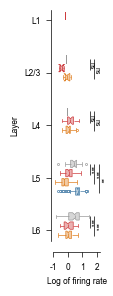

In [7]:
FIGSIZE = (0.6, 3)

# plot
fig, ax = plt.subplots(1, figsize=FIGSIZE)
ax, df_fr = fr_npx.plot_fr_stats_by_layer_vert(
    ax, df_nv, df_ns, df_ne, df_nb, layers, cl
)

# annotate stats
ax, stats_hash = fr_npx.annotate_stats(ax, df_fr, "firing rate", layers, exps)

# aesthetics
ax.set_xticks([-1, 0, 1, 2], [-1, 0, 1, 2])
ax.set_xlim([-1, 2.2])
ax.set_ylim((4.2, -0.2))

# save figure
plt.savefig("figures/8_source_data/fig4b/fig4b.svg", bbox_inches="tight", **savefig_cfg)

### Create source dataset

In [13]:
df_fr.to_excel("figures/8_source_data/fig4b/fig4b.xlsx", index=False)
display(df_fr)

,firing rate,experiment,layer
96,-0.214670,NS,L1
0,-0.095104,M,L2/3
282,0.181844,E,L2/3
281,-0.094204,E,L2/3
280,0.121669,E,L2/3
...,...,...,...
654,-0.175007,E,L6
655,0.038753,E,L6
656,-0.610834,E,L6
89,0.725912,M,L6


### Load

In [14]:
# load source dataset
df = pd.read_excel("figures/8_source_data/fig4b/fig4b.xlsx")

### Re-plot

L1 - M vs. NS, z="nan", p="nan", N_m=0, N_target=1
L1 - M vs. E, z="nan", p="nan", N_m=0, N_target=0
L1 - M vs. S, z="nan", p="nan", N_m=0, N_target=0
L2/3 - M vs. NS, z=2.0, p=0.6666666666666666, N_m=1, N_target=2
L2/3 - M vs. E, z=2.0, p=0.75, N_m=1, N_target=7
L2/3 - M vs. S, z="nan", p="nan", N_m=1, N_target=0
L4 - M vs. NS, z=7.0, p=0.5925925925925926, N_m=1, N_target=26
L4 - M vs. E, z=14.0, p=0.7430443884421085, N_m=1, N_target=36
L4 - M vs. S, z="nan", p="nan", N_m=1, N_target=0
L5 - M vs. NS, z=1762.0, p=0.00021906962945158874, N_m=20, N_target=116
L5 - M vs. E, z=5195.0, p=4.308049410500526e-08, N_m=20, N_target=300
L5 - M vs. S, z=2401.5, p=0.006226991702636302, N_m=20, N_target=377
L6 - M vs. NS, z=2080.0, p=0.00012100711593427902, N_m=74, N_target=39
L6 - M vs. E, z=3467.0, p=2.7313165982394883e-06, N_m=74, N_target=64
L6 - M vs. S, z="nan", p="nan", N_m=74, N_target=0


(4.2, -0.2)

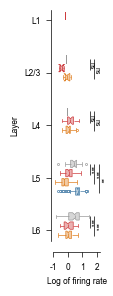

In [ ]:
import seaborn as sns

BOXPLOT_PMS = {
    "notch": True,  # notches are 95% CI
    "gap": 0.2,
    "width": 0.7,
    "linewidth": 0.5,
    "flierprops": {
        "marker": "o",
        "markerfacecolor": "w",
        "markersize": 1.5,
        "markeredgewidth": 0.5,
    },
    "boxprops": {"linewidth": 0.5},
}
alpha = 0.4

FIGSIZE = (0.6, 3)
fig, ax = plt.subplots(1, figsize=FIGSIZE)

ax = sns.boxplot(
    ax=ax,
    data=df,
    x="firing rate",
    y="layer",
    hue="experiment",
    hue_order=["M", "NS", "E", "S"],
    palette=[cl["COLOR_NV"], cl["COLOR_NS"], cl["COLOR_NE"], cl["COLOR_NB"]],
    **BOXPLOT_PMS,
    vert=False,
)

# axes
ax.spines[["top", "right"]].set_visible(False)
ax.legend("", frameon=False)

# disconnect axes (R style)
ax.spines["bottom"].set_position(("axes", -0.05))
ax.yaxis.set_ticks_position("left")
ax.spines["left"].set_position(("axes", -0.05))
ax.set_ylabel("Layer")
ax.set_xlabel("Log of firing rate")

ax = fr_npx.set_aes_boxes(ax, alpha)

# annotate stats
ax, stats_hash = fr_npx.annotate_stats(ax, df, "firing rate", layers, exps)

# aesthetics
ax.set_xticks([-1, 0, 1, 2], [-1, 0, 1, 2])
ax.set_xlim([-1, 2.2])
ax.set_ylim((4.2, -0.2))

### Firing rate stats

In [17]:
def get_ci95(data):
    return 1.96 * np.nanstd(data) / np.sqrt(np.sum(~np.isnan(data)))

In [ ]:
from scipy.stats import mannwhitneyu

print("\nMEDIAN\n")

# report descriptive stats
m_fr = np.median(df_nv[df_nv.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("M: median firing rate (across layers):", m_fr)

ns_fr = np.median(df_ns[df_ns.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("NS: median firing rate (across layers):", ns_fr)

e_fr = np.median(df_ne[df_ne.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("E: median firing rate (across layers):", e_fr)

nb_fr = np.median(df_nb[df_nb.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("E: median firing rate (across layers):", nb_fr)


print("\nCI95\n")

# report descriptive stats
m_fr_s = get_ci95(df_nv[df_nv.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("M: std firing rate (across layers):", m_fr_s)

ns_fr_s = get_ci95(df_ns[df_ns.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("NS: std firing rate (across layers):", ns_fr_s)

e_fr_s = get_ci95(df_ne[df_ne.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("E: std firing rate (across layers):", e_fr_s)

nb_fr_s = get_ci95(df_nb[df_nb.layer.isin(["L5", "L6"])]["firing_rate"].astype(float))
print("E: std firing rate (across layers):", nb_fr_s)


# calculate Mann-Whitney U test
z_ns, p_ns = mannwhitneyu(
    df_nv[df_nv.layer.isin(["L5", "L6"])]["firing_rate"].astype(float).values,
    df_ns[df_ns.layer.isin(["L5", "L6"])]["firing_rate"].astype(float).values,
    method="auto",
)

z_e, p_e = mannwhitneyu(
    df_nv[df_nv.layer.isin(["L5", "L6"])]["firing_rate"].astype(float).values,
    df_ne[df_ne.layer.isin(["L5", "L6"])]["firing_rate"].astype(float).values,
    method="auto",
)

z_nb, p_nb = mannwhitneyu(
    df_nv[df_nv.layer.isin(["L5", "L6"])]["firing_rate"].astype(float).values,
    df_nb[df_nb.layer.isin(["L5", "L6"])]["firing_rate"].astype(float).values,
    method="auto",
)

print("\nGlobal stats:\n")

print("M vs. NS - z", z_ns, "p", p_ns)
print("M vs. NE - z", z_e, "p", p_e)
print("M vs. NB - z", z_nb, "p", p_nb)


MEDIAN

M: median firing rate (across layers): 2.847499966621399
NS: median firing rate (across layers): 1.1549999713897705
E: median firing rate (across layers): 0.6550000011920929
E: median firing rate (across layers): 4.918333530426025

CI95

M: std firing rate (across layers): 1.1371628743938729
NS: std firing rate (across layers): 0.20717812132296998
E: std firing rate (across layers): 0.08338552535088392
E: std firing rate (across layers): 0.41854146406576764

Global stats:

M vs. NS - z 10560.0 p 2.791024005311991e-09
M vs. NE - z 27978.5 p 2.0652632622693254e-21
M vs. NB - z 13109.0 p 9.451295678128557e-05
